### Simple linear regression

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
df = pd.read_csv("../../data/height_weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


**Check realtionship between feature and target**
- Does there seem to be a relationship?

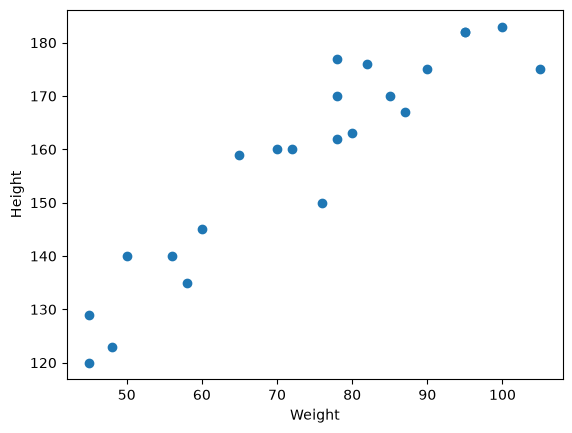

In [86]:
plt.scatter(df["Weight"], df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

**Correlation**
- How strong is the linear relationship?

In [87]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


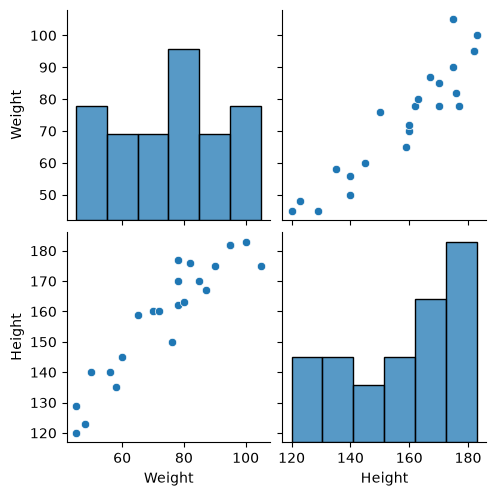

In [88]:
## seaborn for visulazation
sns.pairplot(df);

**Divide the data independent and dependent**

In [89]:
X = df.iloc[:,0:1]    # Independent feature --> it should be dataframe or 2 dimensional
y = df.iloc[:,-1]     # dependent feature

**Split the data into train, test, split**

In [90]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.25,
                                                    random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17, 1), (6, 1), (17,), (6,))

**Standarization**

In [91]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test= scaler.transform(X_test)

We don't use fit_transform() on the test dataset because fit() learns parameters from the data, such as the mean and standard deviation. If we fit the scaler on the test data, we are using information from the test set during preprocessing, which causes data leakage

**Train the model**

In [92]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.3]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,156.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


In [93]:
print(f"intercept: {model.intercept_}")
print(f"coefficient: {model.coef_}")

intercept: 156.47058823529412
coefficient: [17.2982057]


**Visualization**

plot training data best fit line

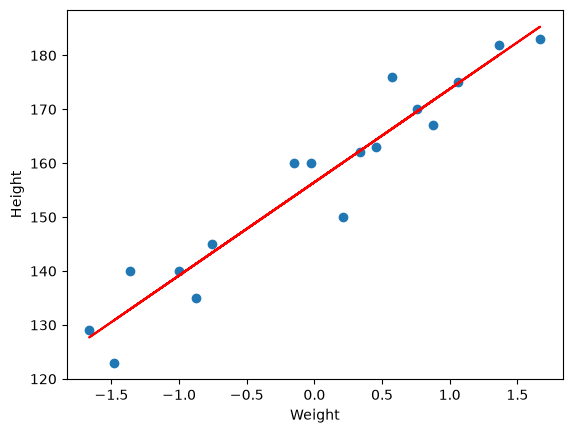

In [94]:
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train), c='r')
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

**Predication for test data**
```text
predicated height output = intercept + coef_(Weight)
y_pred = 156.47 + 17.29 * Weight
```

In [95]:
y_pred =model.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

**Performance Matrix**

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MSE: 114.84069295228699
MAE: 9.665125886795005
RMSE: 10.716374991212605


In [97]:
from sklearn.metrics import r2_score
score= r2_score(y_test, y_pred)
score

0.7360826717981276

In [98]:
# Adjusted R2
n = X_test.shape[0] 
p = X_test.shape[1]   
adjusted_r2 = 1 - ((1 - score) * (n - 1) / (n - p - 1))
adjusted_r2

0.6701033397476595

**OLS method**

In [99]:
import statsmodels.api as sm
ols_model = sm.OLS(y_train, X_train).fit()

In [100]:
pred = ols_model.predict(X_test)
pred

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [101]:
print(ols_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Wed, 23 Sep 2026   Prob (F-statistic):                       0.664
Time:                        08:26:57   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

**Predication for new data**

In [102]:
model.predict(scaler.transform([[72]]))

c:\Users\avina\anaconda3\envs\ml-learning\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])